# Incidentes (No supervisado)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from pathlib import Path

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
# 1) Carga robusta del CSV objetivo (funciona desde raíz o desde Analisis)
from pathlib import Path
import pandas as pd

nombre_csv = "incidentes_2026-05-28_17-09-42.csv"
cwd = Path.cwd()

candidatas = [
    cwd / nombre_csv,                    # si el notebook corre desde Data
    cwd / "Data" / nombre_csv,           # si corre desde la raíz del proyecto
    cwd.parent / "Data" / nombre_csv,    # si corre desde Analisis/
    cwd / ".." / "Data" / nombre_csv,    # ruta relativa alternativa
]

ruta_csv = next((p for p in candidatas if p.exists()), None)

if ruta_csv is None:
    buscados = "\n".join(str(p.resolve()) for p in candidatas)
    raise FileNotFoundError(f"No existe el archivo en ninguna ruta candidata:\n{buscados}")

print("Archivo seleccionado:", ruta_csv.resolve())

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="latin-1",
    dtype=str,
    engine="python",
    on_bad_lines="skip"
)

print("Dimensiones:", df.shape)
display(df.head(3))
print("\nColumnas:")
print(df.columns.tolist())


Archivo seleccionado: C:\Users\paomaribel\Documents\GitHub\Asignador\Data\incidentes_2026-05-28_17-09-42.csv
Dimensiones: (23147, 28)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,short_description,...,reopen_count,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error
0,INC0909337,Nuevo,28/05/2026 16:44:55,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,BancsLink,Estimados por favor su ayuda ya que tengo dife...,...,0,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,NaN,Estimados por favor su ayuda ya que tengo dife...,NaN,NaN,NaN,NaN,NaN
1,INC0909253,En proceso,28/05/2026 15:39:25,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,Bancs,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,...,0,Agencia,TEC_TCS_N1_RYR_APLICACIONES,JOSEPH ANGELO HERRERA GUERRA,Estimados su gentil ayuda no permite sacar e r...,NaN,NaN,NaN,NaN,NaN
2,INC0909222,En proceso,28/05/2026 15:24:21,Aplicaciones,PRODUCCION,APLICACIONES DE BANCO,Self Service,NaN,BancsLink,no permite generar la chequera de la cuenta 21...,...,0,Agencia,TEC_TCS_N1_RYR_APLICACIONES,JOSEPH ANGELO HERRERA GUERRA,estimados no me deja solicitar la chequera de ...,28/05/2026 16:27:31 - LIGIA MAGALI PILA SALAZA...,NaN,NaN,NaN,NaN



Columnas:
['number', 'state', 'sys_created_on', 'category', 'u_subcategory', 'u_subcategory_2', 'contact_type', 'business_duration', 'cmdb_ci_business_app', 'short_description', 'priority', 'severity', 'caller_id', 'u_affected_user', 'u_affected_user.title', 'u_affected_user.department', 'u_affected_user.company', 'location', 'reopen_count', 'location.cmn_location_type', 'assignment_group', 'assigned_to', 'description', 'comments_and_work_notes', 'resolved_at', 'close_notes', 'u_categoria_error', 'u_subcategoria_error']


In [5]:
# 2) Definir columnas para modelado no supervisado
cols_texto = ["short_description", "description"]
faltantes = [c for c in cols_texto if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas críticas: {faltantes}")

# Solo dejamos columnas útiles para esta fase
cols_base = [c for c in ["number", "state"] if c in df.columns] + cols_texto
df_eda = df[cols_base].copy()

print("Columnas en df_eda:", df_eda.columns.tolist())
print("Registros:", len(df_eda))
display(df_eda.head(3))

Columnas en df_eda: ['number', 'state', 'short_description', 'description']
Registros: 23147


,number,state,short_description,description
0,INC0909337,Nuevo,Estimados por favor su ayuda ya que tengo dife...,Estimados por favor su ayuda ya que tengo dife...
1,INC0909253,En proceso,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,Estimados su gentil ayuda no permite sacar e r...
2,INC0909222,En proceso,no permite generar la chequera de la cuenta 21...,estimados no me deja solicitar la chequera de ...


In [7]:
# 3) Calidad de datos de texto: nulos, vacíos, cardinalidad

def es_vacio(x):
    if pd.isna(x):
        return True
    s = str(x).strip().lower()
    return s in {"", "nan", "none", "null"}

resumen_calidad = []
for c in cols_texto:
    vacios = df_eda[c].apply(es_vacio).sum()
    resumen_calidad.append({
        "columna": c,
        "n_registros": len(df_eda),
        "n_vacios": int(vacios),
        "pct_vacios": round(vacios / len(df_eda) * 100, 2),
        "n_unicos_no_nulos": int(df_eda[c].nunique(dropna=True))
    })

resumen_calidad = pd.DataFrame(resumen_calidad)
display(resumen_calidad)

,columna,n_registros,n_vacios,pct_vacios,n_unicos_no_nulos
0,short_description,23147,0,0.00,18164
1,description,23147,299,1.29,18033


In [8]:
# 4) Construir texto unificado SOLO con short_description + description
df_eda["texto_unificado_raw"] = (
    df_eda["short_description"].fillna("").astype(str).str.strip() + " " +
    df_eda["description"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

df_eda["texto_vacio"] = df_eda["texto_unificado_raw"].eq("")

print("Registros sin texto útil:", int(df_eda["texto_vacio"].sum()))
print("Porcentaje sin texto útil:", round(df_eda["texto_vacio"].mean() * 100, 2), "%")
display(df_eda[["texto_unificado_raw", "texto_vacio"]].head(5))

Registros sin texto útil: 0
Porcentaje sin texto útil: 0.0 %


,texto_unificado_raw,texto_vacio
0,Estimados por favor su ayuda ya que tengo dife...,False
1,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESE...,False
2,no permite generar la chequera de la cuenta 21...,False
3,estimados por favor su ayuda ya que tengo dife...,False
4,Evento Productivo - 1 synthetic monitors: Http...,False


In [9]:
# 5) Duplicados exactos (muy importante para clustering)
dup_pair = df_eda[cols_texto].fillna("").duplicated(keep=False)
dup_texto = df_eda["texto_unificado_raw"].duplicated(keep=False)

print("Duplicados por (short_description, description):", int(dup_pair.sum()))
print("Duplicados por texto_unificado_raw:", int(dup_texto.sum()))

# Muestra de ejemplos duplicados
ej_dup = df_eda.loc[dup_texto, ["number", "short_description", "description", "texto_unificado_raw"]].head(10)
display(ej_dup)

Duplicados por (short_description, description): 2859
Duplicados por texto_unificado_raw: 3491


,number,short_description,description,texto_unificado_raw
12,INC0908346,Proceso cancelado RC_BSD_EOD_MONITOR TEST,Estimados Se informa que el proceso RC_BSD_EO...,Proceso cancelado RC_BSD_EOD_MONITOR TEST Esti...
21,INC0908187,Proceso Cancelado BRC_DEPD5555 TEST,"Estimados, Se informa que el proceso cancela,...","Proceso Cancelado BRC_DEPD5555 TEST Estimados,..."
22,INC0908183,Proceso Cancelado RC_BBV_VALIDA_JR_PROCCESSCM ...,"Estimados, Se informa que el proceso cancela,...",Proceso Cancelado RC_BBV_VALIDA_JR_PROCCESSCM ...
25,INC0908124,Proceso Cancelado RC_BVP_AFTER_DEBIT_BOF_112 TEST,"Estimados, Se informa que el proceso cancela,...",Proceso Cancelado RC_BVP_AFTER_DEBIT_BOF_112 T...
42,INC0907747,Tiempos excedidos infd5124cmms,"Estimados, Se informa que el proceso lleva t...","Tiempos excedidos infd5124cmms Estimados, Se i..."
47,INC0907543,Tiempos excedidos lond0856,"Estimados, Se informa que el proceso lleva t...","Tiempos excedidos lond0856 Estimados, Se infor..."
56,INC0907036,Proceso Cancelado infd1318,"Estimados, Se informa que el proceso cancela,...","Proceso Cancelado infd1318 Estimados, Se infor..."
58,INC0906929,Proceso Cancelado depd0128,"Estimados, Se informa que el proceso cancela,...","Proceso Cancelado depd0128 Estimados, Se infor..."
66,INC0906643,Proceso cancelado infd2806 PREPROD,Estimados saludos Favor su ayuda validando e...,Proceso cancelado infd2806 PREPROD Estimados s...
67,INC0906642,Proceso cancelado infd0127 PREPROD,Estimados saludos Favor su ayuda validando e...,Proceso cancelado infd0127 PREPROD Estimados s...


          len_chars     len_words
count  23147.000000  23147.000000
mean     556.728475     67.907375
std     2636.029396    281.215873
min       17.000000      2.000000
25%      121.000000     17.000000
50%      187.000000     24.000000
75%      313.000000     44.000000
90%      425.000000     69.000000
95%      690.000000    108.000000
99%    11609.900000   1331.160000
max    31820.000000   5150.000000


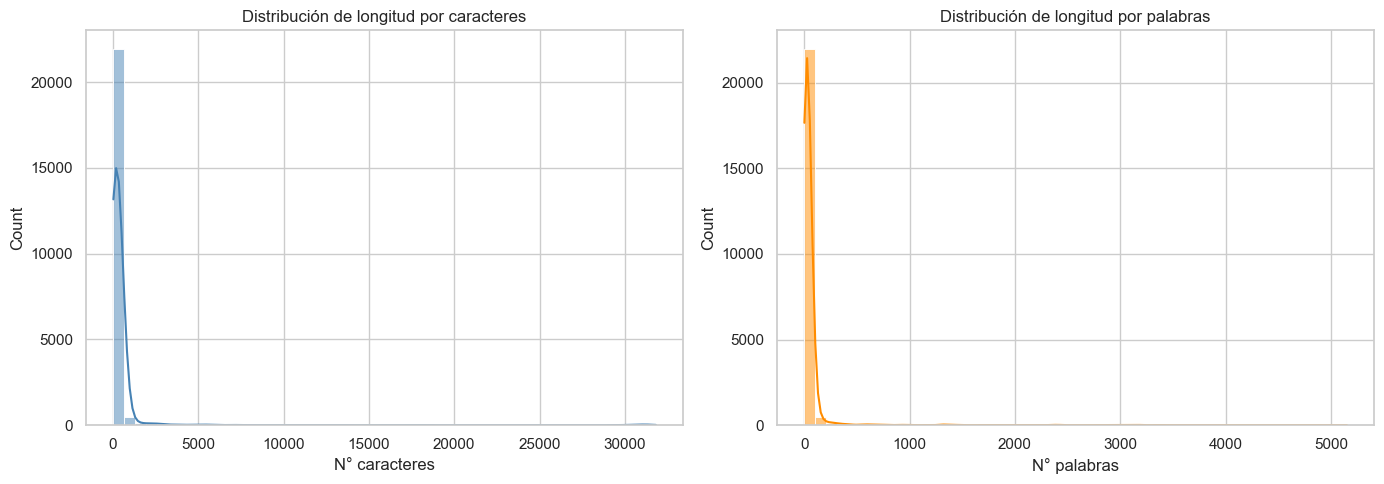

In [10]:
# 6) Longitud del texto: chars y palabras
df_len = df_eda.loc[~df_eda["texto_vacio"]].copy()
df_len["len_chars"] = df_len["texto_unificado_raw"].str.len()
df_len["len_words"] = df_len["texto_unificado_raw"].str.split().str.len()

print(df_len[["len_chars", "len_words"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_len["len_chars"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de longitud por caracteres")
ax[0].set_xlabel("N° caracteres")

sns.histplot(df_len["len_words"], bins=50, kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de longitud por palabras")
ax[1].set_xlabel("N° palabras")

plt.tight_layout()
plt.show()

In [11]:
# 7) Señal de "plantillas" repetitivas en short_description
top_short = (
    df_eda["short_description"]
    .fillna("VACIO")
    .astype(str)
    .str.strip()
    .value_counts()
    .head(15)
)

print("Top 15 short_description más frecuentes:")
display(top_short.to_frame("frecuencia"))

Top 15 short_description más frecuentes:


,frecuencia
short_description,
Fallo la ejecucion del Proceso repcoscm,76
Fallo la ejecucion del Proceso sec_update_1,63
Fallo la ejecucion del Proceso infd6024cm,53
Evento Productivo - PRECBPHCAP: DISCO Saturation AIX DCP,46
Fallo la ejecucion del Proceso sglo1057_factrec,44
Evento Productivo - precbphcap DISCO Saturation,39
Evento productivo - Http monitor global outage_BancsLink en ecuio012bc3 SisRep,33
Fallo la ejecucion del Proceso camRepCanjeEn_f1,31
Proceso Cancelado sh0191cm,29


# Limpieza inicial - Requerimientos (No supervisado)

Objetivo: limpieza de datos previa al modelado

In [12]:
# 8) Separar dataset de modelado (solo texto) y dataset de auditoría
# number se conserva SOLO para trazabilidad, no para features
df_model = df_eda[["number", "short_description", "description"]].copy()

print("Registros base:", len(df_model))
display(df_model.head(3))

Registros base: 23147


,number,short_description,description
0,INC0909337,Estimados por favor su ayuda ya que tengo dife...,Estimados por favor su ayuda ya que tengo dife...
1,INC0909253,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,Estimados su gentil ayuda no permite sacar e r...
2,INC0909222,no permite generar la chequera de la cuenta 21...,estimados no me deja solicitar la chequera de ...


In [13]:
# 9) Limpieza textual robusta para clustering
import re
import unicodedata

def normalize_text(texto):
    if pd.isna(texto):
        return ""

    t = str(texto).strip().lower()

    # Normaliza unicode y elimina caracteres raros
    t = unicodedata.normalize("NFKD", t)
    t = t.encode("ascii", "ignore").decode("utf-8", errors="ignore")

    # Enmascarar patrones que meten ruido semantico
    t = re.sub(r"(https?://\S+|www\.\S+)", " url ", t)
    t = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", t)
    t = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " fecha ", t)
    t = re.sub(r"\b\d{7,}\b", " num_largo ", t)   # cuentas, RUC, teller, etc.
    t = re.sub(r"\b\d+\b", " num ", t)

    # Limpieza general
    t = re.sub(r"[_\-=/\\\|\(\)\[\]\{\},;:]+", " ", t)
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()

    return t

In [14]:
# 10) Limpiar columnas textuales
df_model["short_clean"] = df_model["short_description"].apply(normalize_text)
df_model["desc_clean"] = df_model["description"].apply(normalize_text)

# short_description suele ser plantilla; description lleva mas señal
# Damos mayor peso a description repitiendola una vez adicional
df_model["texto_limpio"] = (
    df_model["short_clean"] + " " +
    df_model["desc_clean"] + " " +
    df_model["desc_clean"]
).str.replace(r"\s+", " ", regex=True).str.strip()

display(df_model[["short_description", "description", "texto_limpio"]].head(3))

,short_description,description,texto_limpio
0,Estimados por favor su ayuda ya que tengo dife...,Estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...
1,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,Estimados su gentil ayuda no permite sacar e r...,reportes en bancs no permite mayor a tres mese...
2,no permite generar la chequera de la cuenta 21...,estimados no me deja solicitar la chequera de ...,no permite generar la chequera de la cuenta nu...


In [15]:
# Validación de limpieza
muestra_validacion = df_model[[
    "number", "short_description", "description", "short_clean", "desc_clean", "texto_limpio"
]].head(10).copy()

display(muestra_validacion)

print("Conteo de placeholders en texto_limpio:")
print("fecha:", int(df_model["texto_limpio"].str.contains(r"\bfecha\b", regex=True).sum()))
print("num_largo:", int(df_model["texto_limpio"].str.contains(r"\bnum_largo\b", regex=True).sum()))
print("num:", int(df_model["texto_limpio"].str.contains(r"\bnum\b", regex=True).sum()))
print("email:", int(df_model["texto_limpio"].str.contains(r"\bemail\b", regex=True).sum()))
print("url:", int(df_model["texto_limpio"].str.contains(r"\burl\b", regex=True).sum()))

print("\nConteo de caracteres raros remanentes:")
print(" :", int(df_model["texto_limpio"].str.contains("", regex=False).sum()))
print("� :", int(df_model["texto_limpio"].str.contains("�", regex=False).sum()))
print("¿ :", int(df_model["texto_limpio"].str.contains("¿", regex=False).sum()))
print("¡ :", int(df_model["texto_limpio"].str.contains("¡", regex=False).sum()))

,number,short_description,description,short_clean,desc_clean,texto_limpio
0,INC0909337,Estimados por favor su ayuda ya que tengo dife...,Estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...
1,INC0909253,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,Estimados su gentil ayuda no permite sacar e r...,reportes en bancs no permite mayor a tres meses,estimados su gentil ayuda no permite sacar e r...,reportes en bancs no permite mayor a tres mese...
2,INC0909222,no permite generar la chequera de la cuenta 21...,estimados no me deja solicitar la chequera de ...,no permite generar la chequera de la cuenta nu...,estimados no me deja solicitar la chequera de ...,no permite generar la chequera de la cuenta nu...
3,INC0909157,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...
4,INC0908960,Evento Productivo - 1 synthetic monitors: Http...,P-260575421 https://xyc10065.live.dynatrace.co...,evento productivo num synthetic monitors http ...,p num largo url,evento productivo num synthetic monitors http ...
5,INC0908670,CLIENTE NO CREADO EN RIESGO GLOBAL,El cliente JP CONSTRUCRED C.L.TDA con identif...,cliente no creado en riesgo global,el cliente jp construcred c l tda con identifi...,cliente no creado en riesgo global el cliente ...
6,INC0908595,ESTOY INTENTANDO BAJAR REPORTES Y ME SALE QUE ...,ESTOY INTENTANDO BAJAR REPORTES DE CHEQUES DEV...,estoy intentando bajar reportes y me sale que ...,estoy intentando bajar reportes de cheques dev...,estoy intentando bajar reportes y me sale que ...
7,INC0908579,Proceso cancelado chfsplit TEST,"Estimados Se informa que el proceso cancela, ...",proceso cancelado chfsplit test,estimados se informa que el proceso cancela se...,proceso cancelado chfsplit test estimados se i...
8,INC0908562,Proceso cancelado infd1318 PRODUCCION,Estimados saludos Favor su ayuda validando e...,proceso cancelado infd1318 produccion,estimados saludos favor su ayuda validando el ...,proceso cancelado infd1318 produccion estimado...
9,INC0908538,ERROR MOTOR TRANSFERENCIAS NO EXISTE PARAMETR...,Estimados. por favor su gentil ayuda con la so...,error motor transferencias no existe parametri...,estimados por favor su gentil ayuda con la sol...,error motor transferencias no existe parametri...


Conteo de placeholders en texto_limpio:
fecha: 3311
num_largo: 0
num: 11278
email: 285
url: 2488

Conteo de caracteres raros remanentes:
 : 0
� : 0
¿ : 0
¡ : 0


In [16]:
# 11) Filtrar textos no informativos
df_model["n_tokens"] = df_model["texto_limpio"].str.split().str.len()

# Regla base: al menos 4 tokens utiles
df_model["valido_modelo"] = df_model["n_tokens"] >= 4

print("Registros validos para modelo:", int(df_model["valido_modelo"].sum()))
print("Registros descartados por poco texto:", int((~df_model["valido_modelo"]).sum()))

display(df_model.loc[~df_model["valido_modelo"], ["number", "texto_limpio", "n_tokens"]].head(10))

Registros validos para modelo: 23145
Registros descartados por poco texto: 2


,number,texto_limpio,n_tokens
22260,INC0061508,encolamiento cif depq,3
22348,INC0059679,encolamienro pfdm,2


In [17]:
# 12) Crear dataset de entrenamiento para clustering
df_fit_full = df_model.loc[df_model["valido_modelo"], ["number", "texto_limpio"]].copy()

# Deduplicado exacto SOLO para ajustar modelo sin sesgo por repeticion
df_fit_unique = (
    df_fit_full
    .drop_duplicates(subset=["texto_limpio"])
    .reset_index(drop=True)
)

print("Registros para fit (con repetidos):", len(df_fit_full))
print("Registros para fit (texto unico):", len(df_fit_unique))
print("Reduccion:", round((1 - len(df_fit_unique) / len(df_fit_full)) * 100, 2), "%")

Registros para fit (con repetidos): 23145
Registros para fit (texto unico): 18003
Reduccion: 22.22 %


In [18]:
# 13) Frecuencia de textos (importante para analisis operativo)
freq_texto = (
    df_fit_full
    .groupby("texto_limpio", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5)))
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto.head(15))

,texto_limpio,frecuencia,ejemplos_number
0,su ayuda con la correccion del error en saldos...,79,"INC0722719, INC0719315, INC0718421, INC0707209..."
1,fallo la ejecucion del proceso repcoscm mail m...,76,"INC0251106, INC0179390, INC0178677, INC0177973..."
2,evento productivo precbphcap disco saturation ...,73,"INC0172139, INC0170920, INC0169802, INC0168638..."
3,fallo la ejecucion del proceso sec update 1 ma...,63,"INC0179239, INC0178580, INC0178069, INC0177818..."
4,fallo la ejecucion del proceso infd6024cm mail...,52,"INC0176833, INC0175727, INC0174612, INC0173580..."
5,fallo la ejecucion del proceso sglo1057 factre...,44,"INC0251108, INC0177984, INC0163480, INC0162354..."
6,evento productivo foecbphca1 disco saturation ...,38,"INC0170962, INC0170688, INC0168655, INC0166528..."
7,evento enp tsecbphca1 low disk space p num lar...,35,"INC0812831, INC0812802, INC0387610, INC0384252..."
8,evento productivo precbphcap saturacion de dis...,35,"INC0333918, INC0332415, INC0327359, INC0327296..."
9,evento productivo b24gwbl connectivity problem...,30,"INC0407198, INC0406372, INC0406303, INC0401915..."


In [19]:
# 14) Objetos que usaremos en clustering
# - df_fit_unique["texto_limpio"] -> entrenamiento del clustering
# - df_fit_full -> para asignar cluster a todos los tickets validos
# - df_model -> para trazabilidad completa por number
print("Listo para clustering no supervisado.")
print("Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto")

Listo para clustering no supervisado.
Variables clave: df_fit_unique, df_fit_full, df_model, freq_texto


In [20]:
# 15) Remover boilerplate de negocio (v5 robusto)

boilerplate_patterns = [
    # Encabezados tipicos de short_description
    r"\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b",
    r"\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b",

    # Saludos y apertura
    r"^\s*estimad[oa]s?\b",
    r"^\s*buen[oa]s?\s+d[ii]as\b",
    r"^\s*buen[oa]s?\s+tardes\b",
    r"^\s*buen[oa]s?\s+noches\b",
    r"\bespero\s+se\s+encuentren\s+bien\b",

    # Frases blandas frecuentes
    r"\bpor\s+favor\b",
    r"\bfavor\b",
    r"\bfavor\s+con\b",
    r"\bsu\s+gentil\s+ayuda\b",
    r"\bsu\s+ayuda\b",
    r"\bsu\s+gentil\s+apoyo\b",
    r"\bsu\s+apoyo\b",
    r"\bgentil\s+apoyo\b",
    r"\bfavor\s+su\s+ayuda\b",
    r"\bpor\s+favor\s+su\s+ayuda\s+con\b",
    r"\bpor\s+favor\s+su\s+apoyo\s+con\b",
    r"\bpor\s+favor\s+apoyar\b",
    r"\bpor\s+favor\s+ayudar\b",
    r"\bsu\s+gentil\s+apoyo\s+con\b",
    r"\bsu\s+ayuda\s+con\b",
    r"\bapoyo\s+con\b",
    r"\bayuda\s+con\b",

    # Cierre y cortesia
    r"\batenta?\s+a\s+sus\s+comentarios\b",
    r"\bquedo\s+atent[oa]\b",
    r"\bde\s+antemano\b",
    r"\bles\s+agradezco\b",
    r"\bagradezco\s+su\s+ayuda\b",
    r"\bcordial(?:es)?\s+saludos\b",
    r"\bsaludos?\s+cordiales?\b",
    r"\bsaludos?\b",
    r"\bgracias\b",
    r"\badjunto\b",
]

boilerplate_regex = re.compile("|".join(boilerplate_patterns))
prefix_regex = re.compile(r"^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+")

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ""
    t = str(texto)

    # 1) quitar boilerplate en varias pasadas
    for _ in range(6):
        t_new = boilerplate_regex.sub(" ", t)
        t_new = re.sub(r"\s+", " ", t_new).strip()
        if t_new == t:
            break
        t = t_new

    # 2) quitar conectores residuales al inicio
    for _ in range(4):
        t_new = prefix_regex.sub("", t).strip()
        if t_new == t:
            break
        t = t_new

    # 3) limpieza final
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_model["short_core"] = df_model["short_clean"].apply(strip_boilerplate)
df_model["desc_core"] = df_model["desc_clean"].apply(strip_boilerplate)

display(df_model[["short_clean", "short_core", "desc_clean", "desc_core"]].head(10))

,short_clean,short_core,desc_clean,desc_core
0,estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la cuenta num largo...,estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la cuenta num largo...
1,reportes en bancs no permite mayor a tres meses,reportes en bancs no permite mayor a tres meses,estimados su gentil ayuda no permite sacar e r...,no permite sacar e reporte en bancs para poder...
2,no permite generar la chequera de la cuenta nu...,no permite generar la chequera de la cuenta nu...,estimados no me deja solicitar la chequera de ...,no me deja solicitar la chequera de la cuenta ...
3,estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la redistribucion p...,estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la redistribucion p...
4,evento productivo num synthetic monitors http ...,evento productivo num synthetic monitors http ...,p num largo url,p num largo url
5,cliente no creado en riesgo global,cliente no creado en riesgo global,el cliente jp construcred c l tda con identifi...,el cliente jp construcred c l tda con identifi...
6,estoy intentando bajar reportes y me sale que ...,estoy intentando bajar reportes y me sale que ...,estoy intentando bajar reportes de cheques dev...,estoy intentando bajar reportes de cheques dev...
7,proceso cancelado chfsplit test,proceso cancelado chfsplit test,estimados se informa que el proceso cancela se...,se informa que el proceso cancela se adjunta e...
8,proceso cancelado infd1318 produccion,proceso cancelado infd1318 produccion,estimados saludos favor su ayuda validando el ...,validando el proceso cancelado
9,error motor transferencias no existe parametri...,error motor transferencias no existe parametri...,estimados por favor su gentil ayuda con la sol...,la solucion del error no existe parametrizacio...


In [21]:
# 16) Construir texto final priorizando description (v3)
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    t = str(txt).strip()
    if t == "":
        return False
    return len(t.split()) >= min_tokens

def construir_texto_final(row):
    d = row["desc_core"] if pd.notna(row["desc_core"]) else ""
    s = row["short_core"] if pd.notna(row["short_core"]) else ""

    d_ok = es_texto_informativo(d, min_tokens=4)
    s_ok = es_texto_informativo(s, min_tokens=4)

    if d_ok and s_ok:
        return (d + " " + s).strip(), "desc_core+short_core"
    if d_ok:
        return d.strip(), "desc_core"
    if s_ok:
        return s.strip(), "short_core"

    # Si ninguno es informativo, no reinyectar short_clean genérico automáticamente
    return "", "none"

tmp = df_model.apply(construir_texto_final, axis=1)
df_model["texto_limpio_v2"] = tmp.apply(lambda x: x[0])
df_model["source_text_v2"] = tmp.apply(lambda x: x[1])

display(df_model[["description", "short_description", "desc_core", "short_core", "texto_limpio_v2", "source_text_v2"]].head(10))
print(df_model["source_text_v2"].value_counts(dropna=False))

,description,short_description,desc_core,short_core,texto_limpio_v2,source_text_v2
0,Estimados por favor su ayuda ya que tengo dife...,Estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la cuenta num largo...,ya que tengo diferencia en la cuenta num largo...,ya que tengo diferencia en la cuenta num largo...,desc_core+short_core
1,Estimados su gentil ayuda no permite sacar e r...,REPORTES EN BANCS NO PERMITE MAYOR A TRES MESES,no permite sacar e reporte en bancs para poder...,reportes en bancs no permite mayor a tres meses,no permite sacar e reporte en bancs para poder...,desc_core+short_core
2,estimados no me deja solicitar la chequera de ...,no permite generar la chequera de la cuenta 21...,no me deja solicitar la chequera de la cuenta ...,no permite generar la chequera de la cuenta nu...,no me deja solicitar la chequera de la cuenta ...,desc_core+short_core
3,estimados por favor su ayuda ya que tengo dife...,estimados por favor su ayuda ya que tengo dife...,ya que tengo diferencia en la redistribucion p...,ya que tengo diferencia en la redistribucion p...,ya que tengo diferencia en la redistribucion p...,desc_core+short_core
4,P-260575421 https://xyc10065.live.dynatrace.co...,Evento Productivo - 1 synthetic monitors: Http...,p num largo url,evento productivo num synthetic monitors http ...,p num largo url evento productivo num syntheti...,desc_core+short_core
5,El cliente JP CONSTRUCRED C.L.TDA con identif...,CLIENTE NO CREADO EN RIESGO GLOBAL,el cliente jp construcred c l tda con identifi...,cliente no creado en riesgo global,el cliente jp construcred c l tda con identifi...,desc_core+short_core
6,ESTOY INTENTANDO BAJAR REPORTES DE CHEQUES DEV...,ESTOY INTENTANDO BAJAR REPORTES Y ME SALE QUE ...,estoy intentando bajar reportes de cheques dev...,estoy intentando bajar reportes y me sale que ...,estoy intentando bajar reportes de cheques dev...,desc_core+short_core
7,"Estimados Se informa que el proceso cancela, ...",Proceso cancelado chfsplit TEST,se informa que el proceso cancela se adjunta e...,proceso cancelado chfsplit test,se informa que el proceso cancela se adjunta e...,desc_core+short_core
8,Estimados saludos Favor su ayuda validando e...,Proceso cancelado infd1318 PRODUCCION,validando el proceso cancelado,proceso cancelado infd1318 produccion,validando el proceso cancelado proceso cancela...,desc_core+short_core
9,Estimados. por favor su gentil ayuda con la so...,ERROR MOTOR TRANSFERENCIAS NO EXISTE PARAMETR...,la solucion del error no existe parametrizacio...,error motor transferencias no existe parametri...,la solucion del error no existe parametrizacio...,desc_core+short_core


source_text_v2
desc_core+short_core    20736
desc_core                1733
short_core                538
none                      140
Name: count, dtype: int64


In [22]:
# 17) Recalcular filtro de textos informativos con v2
df_model["n_tokens_v2"] = df_model["texto_limpio_v2"].str.split().str.len().fillna(0).astype(int)
df_model["valido_modelo_v2"] = df_model["n_tokens_v2"] >= 4

print("Validos v2:", int(df_model["valido_modelo_v2"].sum()))
print("Descartados v2:", int((~df_model["valido_modelo_v2"]).sum()))

print("\nDescarte por fuente:")
display(df_model.loc[~df_model["valido_modelo_v2"], "source_text_v2"].value_counts(dropna=False).to_frame("conteo"))

display(df_model.loc[~df_model["valido_modelo_v2"], ["number", "source_text_v2", "texto_limpio_v2", "n_tokens_v2"]].head(10))

Validos v2: 23007
Descartados v2: 140

Descarte por fuente:


,conteo
source_text_v2,
none,140


,number,source_text_v2,texto_limpio_v2,n_tokens_v2
272,INC0897903,none,,0
1031,INC0863421,none,,0
2842,INC0764504,none,,0
2912,INC0762898,none,,0
3422,INC0729532,none,,0
3946,INC0700306,none,,0
4459,INC0673423,none,,0
4578,INC0664028,none,,0
4757,INC0648376,none,,0
4896,INC0637434,none,,0


In [23]:
# 18) Recalcular fit y deduplicación con v2
df_fit_full_v2 = df_model.loc[df_model["valido_modelo_v2"], ["number", "texto_limpio_v2", "source_text_v2"]].copy()

df_fit_unique_v2 = (
    df_fit_full_v2
    .drop_duplicates(subset=["texto_limpio_v2"])
    .reset_index(drop=True)
)

print("Fit v2 (con repetidos):", len(df_fit_full_v2))
print("Fit v2 (texto unico):", len(df_fit_unique_v2))
print("Reduccion v2:", round((1 - len(df_fit_unique_v2) / len(df_fit_full_v2)) * 100, 2), "%")

Fit v2 (con repetidos): 23007
Fit v2 (texto unico): 17708
Reduccion v2: 23.03 %


In [24]:
# 19) Frecuencias top con v2
freq_texto_v2 = (
    df_fit_full_v2
    .groupby("texto_limpio_v2", as_index=False)
    .agg(
        frecuencia=("number", "count"),
        ejemplos_number=("number", lambda x: ", ".join(x.head(5))),
        fuente_predominante=("source_text_v2", lambda x: x.value_counts().index[0] if len(x) else "NA")
    )
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_texto_v2.head(15))

,texto_limpio_v2,frecuencia,ejemplos_number,fuente_predominante
0,se informa que el proceso cancela se adjunta l...,266,"INC0907036, INC0906929, INC0906092, INC0905461...",desc_core
1,la correccion del error en saldos presentados ...,79,"INC0722719, INC0719315, INC0718421, INC0707209...",desc_core+short_core
2,mail message from control m message se informa...,76,"INC0251106, INC0179390, INC0178677, INC0177973...",desc_core+short_core
3,p num largo url evento productivo precbphcap d...,73,"INC0172139, INC0170920, INC0169802, INC0168638...",desc_core+short_core
4,mail message from control m message se informa...,63,"INC0179239, INC0178580, INC0178069, INC0177818...",desc_core+short_core
5,mail message from control m message se informa...,52,"INC0176833, INC0175727, INC0174612, INC0173580...",desc_core+short_core
6,mail message from control m message se informa...,44,"INC0251108, INC0177984, INC0163480, INC0162354...",desc_core+short_core
7,se informa que el proceso lleva tiempos excedi...,41,"INC0907747, INC0907626, INC0907543, INC0899059...",desc_core
8,p num largo url evento productivo foecbphca1 d...,38,"INC0170962, INC0170688, INC0168655, INC0166528...",desc_core+short_core
9,p num largo url evento enp tsecbphca1 low disk...,35,"INC0812831, INC0812802, INC0387610, INC0384252...",desc_core+short_core


In [25]:
# 20) Comparativa v1 vs v2 en dominancia top1
top1_v1 = freq_texto.iloc[0]["frecuencia"] if len(freq_texto) else 0
top1_v2 = freq_texto_v2.iloc[0]["frecuencia"] if len(freq_texto_v2) else 0

print("Top1 frecuencia v1:", top1_v1)
print("Top1 frecuencia v2:", top1_v2)
if top1_v1 > 0:
    print("Cambio porcentual top1:", round((top1_v2 - top1_v1) / top1_v1 * 100, 2), "%")

Top1 frecuencia v1: 79
Top1 frecuencia v2: 266
Cambio porcentual top1: 236.71 %


# Entrenamiento inicial - Requerimientos (No supervisado)

Objetivo: explorar calidad y estructura de datos para preparar un modelo no supervisado usando únicamente short_description y description.
Variables de fuga como assignment_group y assigned_to no se usarán para modelado.

In [26]:
#Celda 21 - Imports para split y modelado
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

RANDOM_STATE = 42

In [27]:
# 22) Base para split train/val/test (solo textos válidos y únicos)
df_unique = df_fit_unique_v2.copy().reset_index(drop=True)
df_unique = df_unique[df_unique["texto_limpio_v2"].fillna("").str.strip().ne("")].copy()

print("Total textos únicos válidos:", len(df_unique))

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))
print("Check total:", len(train_df) + len(val_df) + len(test_df))

Total textos únicos válidos: 17708
Train: 12395
Validación: 2656
Test: 2657
Check total: 17708


In [30]:
# 23) Vectorizacion + reduccion (fit SOLO con train)

STOP_ES = [
    "de","la","el","los","las","en","y","a","que","se","con","por","para","del","al",
    "su","sus","un","una","como","favor","apoyo","ayuda","gracias","estimado","estimada",
    "hola","buenos","buenas","dia","dias","tarde","tardes","noche","noches"
]

vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm = Normalizer(copy=False)

X_train_tfidf = vectorizer.fit_transform(train_df["texto_limpio_v2"])
X_val_tfidf = vectorizer.transform(val_df["texto_limpio_v2"])
X_test_tfidf = vectorizer.transform(test_df["texto_limpio_v2"])

X_train = norm.fit_transform(svd.fit_transform(X_train_tfidf))
X_val = norm.transform(svd.transform(X_val_tfidf))
X_test = norm.transform(svd.transform(X_test_tfidf))

print("Shapes:")
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Shapes:
Train: (12395, 100)
Val: (2656, 100)
Test: (2657, 100)


In [31]:
# 24) Búsqueda de k con métricas de VALIDACIÓN
k_grid = list(range(8, 31, 2))
rows = []

for k in k_grid:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )
    km.fit(X_train)

    val_labels = km.predict(X_val)
    n_val_clusters = len(np.unique(val_labels))

    if n_val_clusters > 1:
        sil_val = silhouette_score(X_val, val_labels, metric="euclidean")
        db_val = davies_bouldin_score(X_val, val_labels)            # menor es mejor
        ch_val = calinski_harabasz_score(X_val, val_labels)         # mayor es mejor
    else:
        sil_val = np.nan
        db_val = np.nan
        ch_val = np.nan

    rows.append({
        "k": k,
        "silhouette_val": sil_val,
        "davies_bouldin_val": db_val,
        "calinski_harabasz_val": ch_val,
        "inertia_train": km.inertia_,
        "clusters_en_val": int(n_val_clusters)
    })

df_k_eval = pd.DataFrame(rows).sort_values("silhouette_val", ascending=False).reset_index(drop=True)
display(df_k_eval)

best_k = int(df_k_eval.loc[0, "k"])
best_row = df_k_eval.loc[0]

print("=== MÉTRICAS DE VALIDACIÓN (mejor k) ===")
print("k:", best_k)
print("silhouette_val:", round(float(best_row["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(best_row["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(best_row["calinski_harabasz_val"]), 6))
print("clusters_en_val:", int(best_row["clusters_en_val"]))

,k,silhouette_val,davies_bouldin_val,calinski_harabasz_val,inertia_train,clusters_en_val
0,30,0.211600,2.083915,78.910391,6194.635876,30
1,28,0.203989,2.252941,79.534735,6319.414848,28
2,26,0.203819,2.259887,82.787066,6467.076695,26
3,24,0.191778,2.365606,84.653221,6616.709931,24
4,22,0.190755,2.392361,88.097658,6787.469751,22
5,18,0.183656,2.352153,95.009866,7168.917771,18
6,20,0.180446,2.450517,90.834770,6960.009251,20
7,16,0.169768,2.438672,98.248552,7377.217287,16
8,14,0.160278,2.480812,102.692721,7645.278043,14
9,12,0.149210,2.570357,108.183065,7903.894848,12


=== MÉTRICAS DE VALIDACIÓN (mejor k) ===
k: 30
silhouette_val: 0.2116
davies_bouldin_val: 2.083915
calinski_harabasz_val: 78.910391
clusters_en_val: 30


In [32]:
# 25) Reentrenar con train+val y evaluar en TEST (metricas impresas)

trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

vectorizer_tv = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_tv = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_tv = Normalizer(copy=False)

X_trainval_tfidf = vectorizer_tv.fit_transform(trainval_df["texto_limpio_v2"])
X_test_tfidf_tv = vectorizer_tv.transform(test_df["texto_limpio_v2"])

X_trainval = norm_tv.fit_transform(svd_tv.fit_transform(X_trainval_tfidf))
X_test_tv = norm_tv.transform(svd_tv.transform(X_test_tfidf_tv))

kmeans_tv = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_tv.fit(X_trainval)

test_labels = kmeans_tv.predict(X_test_tv)
n_test_clusters = len(np.unique(test_labels))

if n_test_clusters > 1:
    sil_test = silhouette_score(X_test_tv, test_labels, metric="euclidean")
    db_test = davies_bouldin_score(X_test_tv, test_labels)
    ch_test = calinski_harabasz_score(X_test_tv, test_labels)
else:
    sil_test = np.nan
    db_test = np.nan
    ch_test = np.nan

val_best = df_k_eval.loc[df_k_eval["k"] == best_k].iloc[0]

print("=== METRICAS VALIDACION vs TEST ===")
print("k elegido:", best_k)

print("\nValidacion:")
print("silhouette_val:", round(float(val_best["silhouette_val"]), 6))
print("davies_bouldin_val:", round(float(val_best["davies_bouldin_val"]), 6))
print("calinski_harabasz_val:", round(float(val_best["calinski_harabasz_val"]), 6))

print("\nTest:")
print("silhouette_test:", round(float(sil_test), 6) if pd.notna(sil_test) else np.nan)
print("davies_bouldin_test:", round(float(db_test), 6) if pd.notna(db_test) else np.nan)
print("calinski_harabasz_test:", round(float(ch_test), 6) if pd.notna(ch_test) else np.nan)
print("clusters_en_test:", int(n_test_clusters))

=== METRICAS VALIDACION vs TEST ===
k elegido: 30

Validacion:
silhouette_val: 0.2116
davies_bouldin_val: 2.083915
calinski_harabasz_val: 78.910391

Test:
silhouette_test: 0.198801
davies_bouldin_test: 2.242038
calinski_harabasz_test: 75.626319
clusters_en_test: 30


In [33]:
# 26) Modelo final operativo (fit con TODOS los textos unicos validos)

vectorizer_final = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode",
    stop_words=STOP_ES
)

svd_final = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
norm_final = Normalizer(copy=False)

X_unique_tfidf = vectorizer_final.fit_transform(df_fit_unique_v2["texto_limpio_v2"])
X_unique = norm_final.fit_transform(svd_final.fit_transform(X_unique_tfidf))

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)
kmeans_final.fit(X_unique)

print("Modelo final ajustado con k =", best_k)

Modelo final ajustado con k = 30


In [34]:
# 27) Asignación de clusters a válidos y manejo explícito de NONE (robusto)

# 27.1 Asignar cluster a todos los válidos (con repetidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
df_fit_full_v2 = df_fit_full_v2.copy()
df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

# 27.2 Llevar resultados al universo completo
df_result = df_model.copy()

tmp_assign = (
    df_fit_full_v2[["number", "cluster_id"]]
    .drop_duplicates(subset=["number"])
    .rename(columns={"cluster_id": "cluster_id_pred"})
)

df_result = df_result.merge(tmp_assign, on="number", how="left")

# Conversión robusta
df_result["cluster_id_pred"] = pd.to_numeric(df_result["cluster_id_pred"], errors="coerce")

# No clasificados = -1
df_result["cluster_id"] = df_result["cluster_id_pred"].fillna(-1).astype(int)
df_result = df_result.drop(columns=["cluster_id_pred"])

# Etiqueta final
df_result["estado_cluster"] = np.where(
    df_result["cluster_id"] == -1,
    "none_no_clasificable",
    "cluster_asignado"
)

print(df_result["estado_cluster"].value_counts(dropna=False))
display(df_result[["number", "texto_limpio_v2", "source_text_v2", "cluster_id", "estado_cluster"]].head(15))

estado_cluster
cluster_asignado        23007
none_no_clasificable      140
Name: count, dtype: int64


,number,texto_limpio_v2,source_text_v2,cluster_id,estado_cluster
0,INC0909337,ya que tengo diferencia en la cuenta num largo...,desc_core+short_core,20,cluster_asignado
1,INC0909253,no permite sacar e reporte en bancs para poder...,desc_core+short_core,21,cluster_asignado
2,INC0909222,no me deja solicitar la chequera de la cuenta ...,desc_core+short_core,17,cluster_asignado
3,INC0909157,ya que tengo diferencia en la redistribucion p...,desc_core+short_core,20,cluster_asignado
4,INC0908960,p num largo url evento productivo num syntheti...,desc_core+short_core,24,cluster_asignado
5,INC0908670,el cliente jp construcred c l tda con identifi...,desc_core+short_core,2,cluster_asignado
6,INC0908595,estoy intentando bajar reportes de cheques dev...,desc_core+short_core,22,cluster_asignado
7,INC0908579,se informa que el proceso cancela se adjunta e...,desc_core+short_core,1,cluster_asignado
8,INC0908562,validando el proceso cancelado proceso cancela...,desc_core+short_core,25,cluster_asignado
9,INC0908538,la solucion del error no existe parametrizacio...,desc_core+short_core,29,cluster_asignado


In [35]:
# 28) Resumen de cobertura y tamaño de clusters

# Si no existe cluster_id en df_fit_full_v2, lo calculamos
if "cluster_id" not in df_fit_full_v2.columns:
    X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
    X_full = norm_final.transform(svd_final.transform(X_full_tfidf))
    df_fit_full_v2 = df_fit_full_v2.copy()
    df_fit_full_v2["cluster_id"] = kmeans_final.predict(X_full).astype(int)

print("Total tickets:", len(df_model))
print("Asignados a cluster:", int((df_result["cluster_id"] != -1).sum()))
print("No clasificables (none):", int((df_result["cluster_id"] == -1).sum()))
print("Porcentaje none:", round((df_result["cluster_id"] == -1).mean() * 100, 2), "%")

cluster_sizes = (
    df_fit_full_v2["cluster_id"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_id")
    .reset_index(name="cantidad")
)

cluster_sizes["pct_sobre_asignados"] = (cluster_sizes["cantidad"] / cluster_sizes["cantidad"].sum() * 100).round(2)
display(cluster_sizes)

Total tickets: 23147
Asignados a cluster: 23007
No clasificables (none): 140
Porcentaje none: 0.6 %


,cluster_id,cantidad,pct_sobre_asignados
0,0,367,1.60
1,1,3290,14.30
2,2,802,3.49
3,3,1277,5.55
4,4,233,1.01
5,5,792,3.44
6,6,404,1.76
7,7,1296,5.63
8,8,1407,6.12
9,9,421,1.83


In [36]:
# 29) Top términos y ejemplos por cluster (sin truncamiento)

import numpy as np
import pandas as pd

# Matriz tfidf del set asignado (válidos)
X_full_tfidf = vectorizer_final.transform(df_fit_full_v2["texto_limpio_v2"])
terms = np.array(vectorizer_final.get_feature_names_out())

top_n_terms = 12
top_n_examples = 5

rows = []
cluster_ids = sorted(df_fit_full_v2["cluster_id"].unique())

for cid in cluster_ids:
    idx = np.where(df_fit_full_v2["cluster_id"].values == cid)[0]
    if len(idx) == 0:
        continue

    mean_tfidf = X_full_tfidf[idx].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n_terms:][::-1]

    # Lista y string completo de top terms
    top_terms_list = terms[top_idx].tolist()
    top_terms_full = " | ".join(top_terms_list)

    rows.append({
        "cluster_id": int(cid),
        "cantidad": int(len(idx)),
        "top_terms_full": top_terms_full
    })

df_cluster_profile = (
    pd.DataFrame(rows)
    .sort_values("cantidad", ascending=False)
    .reset_index(drop=True)
)

# Mostrar sin truncamiento en notebook y también en print
with pd.option_context(
    "display.max_colwidth", None,
    "display.width", None,
    "display.max_columns", None,
    "display.max_rows", None
):
    display(df_cluster_profile)
    print("\n=== TOP TERMS COMPLETOS ===")
    print(df_cluster_profile.to_string(index=False))

print("\n=== EJEMPLOS POR CLUSTER (TEXTO COMPLETO) ===")
for cid in df_cluster_profile["cluster_id"].head(10):
    print(f"\nCluster {int(cid)}")
    muestra = (
        df_fit_full_v2.loc[df_fit_full_v2["cluster_id"] == cid, ["number", "texto_limpio_v2"]]
        .head(top_n_examples)
        .reset_index(drop=True)
    )

    # Impresión completa registro por registro
    for _, row in muestra.iterrows():
        print(f"- {row['number']}: {row['texto_limpio_v2']}")

,cluster_id,cantidad,top_terms_full
0,1,3290,cancela adjunta | cancela | log revision | proceso | adjunta log | informa proceso | informa | log | proceso cancela | adjunta | revision | revision proceso
1,8,1407,error | bancs | no | aplicativo | bancslink | usuario | impresion | link | momento | error bancs | bancs link | ingresar
2,7,1296,test | cancelado test | proceso cancelado | cancelado | proceso | bancs error | sres | error test | sres bancs | error | bancs | test beod
3,3,1277,cuenta | num | largo | num largo | cliente | cuenta num | no | error | num num | ya | pero | esta
4,15,988,cliente | num | largo | num largo | operacion | pago | operacion num | credito | cuota | valor | mora | vencido
5,27,984,ejecucion | fallo | message | aplicacion | ejecucion hhmmss | fallo fecha | fallo ejecucion | archivo log | ejecucion fallo | durante ejecucion | aaaa mm | sub aplicacion
6,13,979,num num | fns | num | file | sh | echo | data | spool | data file | of | num fns | interfaces
7,25,895,proceso cancelado | cancelado | proceso | validando proceso | cancelado proceso | validando | test | cancelado adjunta | produccion | adjunta output | adjunta | preprod
8,20,880,largo num | fecha num | num | fecha | num num | error saldos | saldos | correccion error | usd fecha | expediente num | num largo | largo
9,2,802,num | no | num num | ya | archivo | informacion | bancs | esta | archivos | fecha | validacion | ruta



=== TOP TERMS COMPLETOS ===
 cluster_id  cantidad                                                                                                                                                                                       top_terms_full
          1      3290                                         cancela adjunta | cancela | log revision | proceso | adjunta log | informa proceso | informa | log | proceso cancela | adjunta | revision | revision proceso
          8      1407                                                                             error | bancs | no | aplicativo | bancslink | usuario | impresion | link | momento | error bancs | bancs link | ingresar
          7      1296                                                           test | cancelado test | proceso cancelado | cancelado | proceso | bancs error | sres | error test | sres bancs | error | bancs | test beod
          3      1277                                                                          